# Лабораторная работа №4: Иллюзия восприятия (Adversarial Attacks & XAI)

Задача — обмануть систему распознавания объектов умного дома. Проверить, смогут ли методы интерпретируемости распознать взлом.

**Ключевые концепты:**
* **FGSM (Fast Gradient Sign Method):** Атака в один шаг. Быстрая, но слабая.
* **PGD (Projected Gradient Descent):** Итеративная атака. «Золотой стандарт» взлома.
* **Confidence Tracking:** Мониторинг вероятности целевого класса.
* **XAI Robustness:** Проверка честности тепловых карт на состязательных примерах.


In [1]:
!pip install captum

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import ResNet18_Weights
from captum.attr import Saliency

## Задание 1: Первая попытка (FGSM Attack)

Умный дом должен пропускать кота, но блокировать «Тостеры».

Загрузим предобученную модель resnet18. Используем класс-обертку `NormalizedModel`, который включает нормализацию внутрь модели, чтобы корректно считать градиенты по пикселям относительно исходного изображения.

In [3]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

class NormalizedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
    def forward(self, x):
        return self.model(self.normalize(x))

norm_model = NormalizedModel(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


Загрузим изображение кота и преобразуем его в тензор. Добавляем batch-измерение, так как модель ожидает вход размера [B, C, H, W].

(-0.5, 1483.5, 1499.5, -0.5)

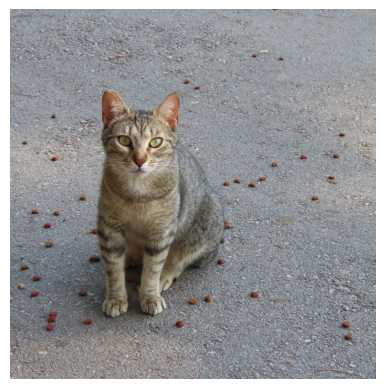

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img = Image.open("cat.jpg").convert("RGB")

input_tensor = transform(img).unsqueeze(0)
input_tensor = input_tensor.clone().detach().requires_grad_(True)

plt.imshow(img)
plt.axis('off')

Прогоним изображение через модель и получим тoп-1 класс и уверенность модели.

In [5]:
labels = ResNet18_Weights.DEFAULT.meta["categories"]

output = norm_model(input_tensor)
probs = torch.nn.functional.softmax(output, dim=1)

top_prob, top_class = probs.max(dim=1)
class_idx = top_class.item()
class_name = labels[class_idx]

print(f"Top-1 класс: {class_idx} ({class_name})")
print("Уверенность:", top_prob.item())

Top-1 класс: 285 (Egyptian cat)
Уверенность: 0.6777713894844055


Найдем индекс класса "toaster" в словаре ImageNet и проверим его вероятность.

In [6]:
toaster_idx = labels.index("toaster")
toaster_prob = probs[0, toaster_idx].item()

print("Индекс toaster:", toaster_idx)
print(f"Вероятность toaster: {toaster_prob:.10f}")

Индекс toaster: 859
Вероятность toaster: 0.0000003168


Для изображения кота вероятность близка к нулю. Модель изначально уверена в правильной классификации
и не склонна относить изображение к классу "toaster".

Реализуем **FGSM (Fast Gradient Sign Method)**. Используем целевую атаку, хотим увеличить вероятность класса "toaster".

Алгоритм: считаем loss относительно класса "toaster", находим градиент по изображению, делаем шаг в направлении антиградиента, чтобы картинка стала максимально похожей на тостер с точки зрения весов нейросети.

In [7]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    # шаг атаки
    perturbed_image = image - epsilon * sign_data_grad
    # ограничиваем диапазон
    return torch.clamp(perturbed_image, 0, 1)

epsilon = 0.1
target = torch.tensor([toaster_idx])
criterion = torch.nn.CrossEntropyLoss()

# обнуляем старые градиенты
input_tensor.grad = None
norm_model.zero_grad()

# прямой проход
output = norm_model(input_tensor)

# ошибка относительно toaster
loss = criterion(output, target)

# обратный
loss.backward()

# градиент изображения
data_grad = input_tensor.grad.data

# создаём атакованное изображение
adv_image = fgsm_attack(input_tensor, epsilon, data_grad)

Пропустим атакованное изображение через модель и посмотрим, изменился ли топ-1 класс и насколько выросла вероятность "toaster".

In [8]:
with torch.no_grad():
    output_adv = norm_model(adv_image)
    probs_adv = torch.nn.functional.softmax(output_adv, dim=1)

top_prob_adv, top_class_adv = probs_adv.max(dim=1)
class_idx = top_class_adv.item()
class_name = labels[class_idx]
print(f"Новый Top-1 класс: {class_idx} ({class_name})")
print("Уверенность:", top_prob_adv.item())

toaster_prob_adv = probs_adv[0, toaster_idx].item()
print(f"Вероятность toaster после FGSM: {toaster_prob_adv:.10f}")

Новый Top-1 класс: 794 (shower curtain)
Уверенность: 0.09907282888889313
Вероятность toaster после FGSM: 0.0001456790


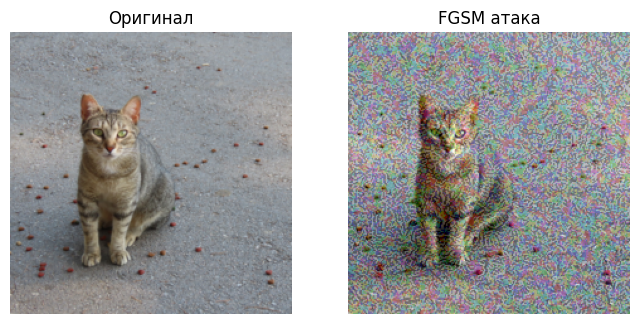

In [9]:
def show_tensor_image(tensor, title):
    img = tensor.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
show_tensor_image(input_tensor, "Оригинал")
plt.subplot(1,2,2)
show_tensor_image(adv_image, "FGSM атака")
plt.show()

После применения FGSM атаки вероятность класса "toaster" увеличилась с 0.0000003 до 0.0001, а уверенность в предсказании снизилась с 0.6 до 0.09, новый тop-1 класс "shower curtain" (занавеска для душа).

Полностью превратить кота в тостер за один шаг не удалось. Атака привела к дестабилизации предсказания: модель перестала уверенно распознавать кота и перешла к нерелевантному классу, не связанному с исходным объектом. Вероятность класса «toaster» при этом хоть и осталась низкой, заметно выросла. Даже небольшие изменения входных данных способны существенно повлиять на предсказание.

Это показывает, что FGSM может ломать модель, но не всегда одного шага хватает, чтобы направленно переводить её в заданный класс.

## Задание 2: Профессиональный взлом (Iterative PGD)


PGD (Projected Gradient Descent) — итеративная версия FGSM. Вместо одного большого шага делаем много маленьких, на каждом шаге двигаемся в сторону целевого класса.

На каждой итерации считаем градиент для текущей картинки, обновляем ее небольшим шагом alpha. Ограничиваем общий шум (ε = 0.1), после каждого шага проецируем изображение обратно в допустимую область.

In [10]:
epsilon = 0.1
alpha = 0.01
iterations = 30

original = input_tensor.detach().clone()
adv_pgd_image = original.clone()

for i in range(iterations+1):
    adv_pgd_image.requires_grad = True

    # Прогоняем через модель
    output = norm_model(adv_pgd_image)

    # ошибка относительно toaster
    loss = criterion(output, target)

    # Считаем градиенты
    norm_model.zero_grad()
    if adv_pgd_image.grad is not None:
        adv_pgd_image.grad.zero_()
    loss.backward()

    # Шаг атаки
    with torch.no_grad():
        adv_pgd_image = adv_pgd_image - alpha * adv_pgd_image.grad.sign()
        # Вычисляем текущую разницу (шум)
        eta = adv_pgd_image - original
        # Обрезаем шум
        eta = torch.clamp(eta, -epsilon, epsilon)
        # Применяем шум к оригиналу
        adv_pgd_image = original + eta
        # Ограничиваем значения пикселей [0, 1]
        adv_pgd_image = torch.clamp(adv_pgd_image, 0, 1)

    if i % 5 == 0:
        with torch.no_grad():
            prob = torch.softmax(norm_model(adv_pgd_image), dim=1)[0, toaster_idx].item()
            print(f"Итерация {i:2d}: Вероятность Тостера = {prob*100:6.2f}%")

Итерация  0: Вероятность Тостера =   0.24%
Итерация  5: Вероятность Тостера =  33.17%
Итерация 10: Вероятность Тостера = 100.00%
Итерация 15: Вероятность Тостера =  96.83%
Итерация 20: Вероятность Тостера =  99.53%
Итерация 25: Вероятность Тостера = 100.00%
Итерация 30: Вероятность Тостера = 100.00%


Уже к 10-й итерации модель начинает с высокой уверенностью классифицировать изображение кота как "toaster". PGD атака значительно эффективнее FGSM. Даже небольшой ограниченный шум способен полностью изменить предсказание модели.

После достижения 100% уверенности вероятность немного колеблется, так как алгоритм продолжает делать шаги и может слегка менять оптимум.

In [11]:
with torch.no_grad():
    output_adv = norm_model(adv_pgd_image)
    probs_adv = torch.softmax(output_adv, dim=1)

top_prob_adv, top_class_adv = probs_adv.max(dim=1)
class_idx = top_class_adv.item()
class_name = labels[class_idx]

print(f"Итоговый Top-1 класс: {class_idx} ({class_name})")
print(f"Уверенность: {top_prob_adv.item()*100:.2f}%")

Итоговый Top-1 класс: 859 (toaster)
Уверенность: 100.00%


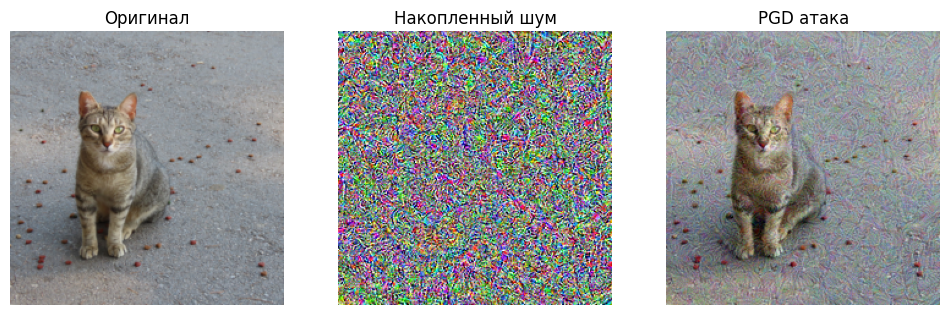

In [12]:
def tensor_to_img(t):
    return t.squeeze().detach().cpu().numpy().transpose(1, 2, 0)

noise = adv_pgd_image - original

plt.figure(figsize=(12,4))

# Оригинал
plt.subplot(1,3,1)
plt.imshow(tensor_to_img(original))
plt.title("Оригинал")
plt.axis('off')

# Шум (нормализованный для визуализации)
noise_vis = tensor_to_img(noise)
noise_vis = (noise_vis - noise_vis.min()) / (noise_vis.max() - noise_vis.min())
plt.subplot(1,3,2)
plt.imshow(noise_vis)
plt.title("Накопленный шум")
plt.axis('off')

# Атакованное изображение
plt.subplot(1,3,3)
plt.imshow(tensor_to_img(adv_pgd_image))
plt.title("PGD атака")
plt.axis('off')

plt.show()

Модель с 100% уверенностью классифицирует изображение как "toaster", теперь это топ-1 класс. Но человеческий глаз не видит тостер на итоговом изображении, это по-прежнему изображение кота, визуально практически не отличающееся от оригинала.

PGD атака показала высокую эффективность: за счёт последовательных малых возмущений
удалось полностью изменить предсказание модели, что демонстрирует уязвимость нейронных сетей к adversarial атакам.

## Задание 3: Следственный эксперимент (Adversarial XAI)

Используем XAI-методы, чтобы понять, почему модель оказалась обманута и где именно она видит тостер.

Используем Saliency, который считает градиент предсказания относительно входных пикселей. Пиксели с самыми большими градиентами подсвечиваются как самые важные.

Отрисуем две тепловые карты:
* Карта А (Оригинал): объяснение чистого изображения кота
* Карта Б (Атака): объяснение взломанного изображения, которое модель считает тостером. Хотим увидеть, подсвечивает ли модель добавленный невидимый шум или по-прежнему смотрит на кота.

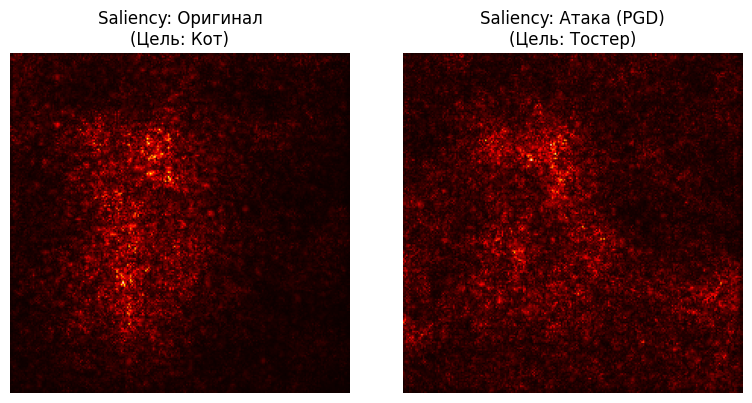

In [13]:
saliency = Saliency(norm_model)

original.requires_grad = True
adv_pgd_image.requires_grad = True
original_class = top_class.item()

# Карта А: Объяснение оригинала
attr_orig = saliency.attribute(original, target=original_class)
# Карта Б: Объяснение атаки
attr_adv = saliency.attribute(adv_pgd_image, target=toaster_idx)

# Тензор атрибуции в тепловую карту
def process_attribution(attr):
    attr = attr.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
    # Абсолютные значения и максимум по цветовым каналам
    attr = np.max(np.abs(attr), axis=2)
    # Нормализация в диапазон [0, 1] для отрисовки
    if attr.max() > 0:
        attr = (attr - attr.min()) / (attr.max() - attr.min())
    return attr

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(process_attribution(attr_orig), cmap='hot')
plt.title(f"Saliency: Оригинал\n(Цель: Кот)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(process_attribution(attr_adv), cmap='hot')
plt.title(f"Saliency: Атака (PGD)\n(Цель: Тостер)")
plt.axis('off')

plt.tight_layout()
plt.show()

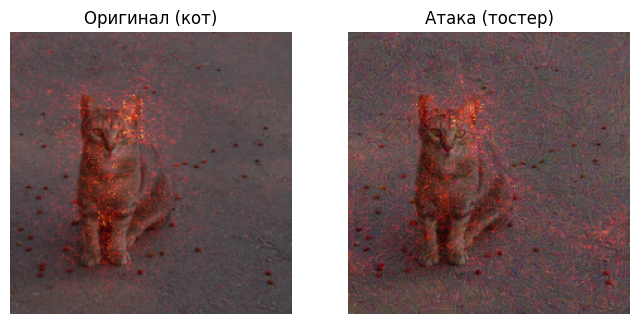

In [14]:
def show_overlay(img_tensor, saliency_map, title):
    img = tensor_to_img(img_tensor)
    plt.imshow(img)
    plt.imshow(saliency_map, cmap='hot', alpha=0.5)
    plt.title(title)
    plt.axis('off')


plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
show_overlay(original, process_attribution(attr_orig), "Оригинал (кот)")
plt.subplot(1,2,2)
show_overlay(adv_pgd_image, process_attribution(attr_adv), "Атака (тостер)")
plt.show()

Saliency не выделяет четких контуров, так как основан на градиентах,
которые являются шумными и нестабильными.

**Карта A** в целом подсвечивает область, где расположен кот. **Карта Б** становится ещё более шумной и показывает, что модель не находит никаких специфических признаков тостера на изображении. Тепловая карта по-прежнему сконцентрирована на морде кота, его ушах и глазах. В областях где нет кота значимых зон активации тоже нет, модель видит тостер именно там, где физически находится кот.

Saliency Map показывает кота, потому что отражает области с наибольшими градиентами, а это контуры и детали (глаза, уши). Шум PGD не создаёт новые объекты, а искажает существующие признаки, заставляя модель интерпретировать их как признаки другого класса. В результате модель принимает решение на основе тонких распределённых изменений,
но её внимание остаётся на исходном объекте — коте.


Таким образом, Saliency Map не является надёжным инструментом
для анализа adversarial атак. Она может показывать размытые или вводящие в заблуждение результаты
и не отражает реальную причину принятия решения моделью.